Dataset Loaded

Training with lambda = 0.001
Lambda 0.001 | Epoch 1 | Loss: 814.27
Lambda 0.001 | Epoch 2 | Loss: 719.52
Lambda 0.001 | Epoch 3 | Loss: 679.41
Lambda 0.001 | Epoch 4 | Loss: 653.70
Lambda 0.001 | Epoch 5 | Loss: 632.85
Lambda 0.001 | Epoch 6 | Loss: 617.28
Lambda 0.001 | Epoch 7 | Loss: 604.68
Lambda 0.001 | Epoch 8 | Loss: 594.85
Lambda 0.001 | Epoch 9 | Loss: 585.59
Lambda 0.001 | Epoch 10 | Loss: 577.38
Lambda: 0.001 | Accuracy: 46.82% | Sparsity: 94.01%

Training with lambda = 0.005
Lambda 0.005 | Epoch 1 | Loss: 816.37
Lambda 0.005 | Epoch 2 | Loss: 716.46
Lambda 0.005 | Epoch 3 | Loss: 682.46
Lambda 0.005 | Epoch 4 | Loss: 656.81
Lambda 0.005 | Epoch 5 | Loss: 635.69
Lambda 0.005 | Epoch 6 | Loss: 618.78
Lambda 0.005 | Epoch 7 | Loss: 606.51
Lambda 0.005 | Epoch 8 | Loss: 596.68
Lambda 0.005 | Epoch 9 | Loss: 587.28
Lambda 0.005 | Epoch 10 | Loss: 579.14
Lambda: 0.005 | Accuracy: 47.08% | Sparsity: 95.27%

Training with lambda = 0.01
Lambda 0.01 | Epoch 1 | Loss: 

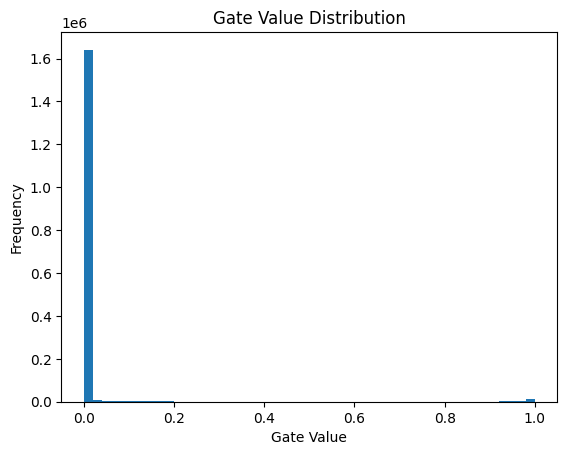

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128)

print("Dataset Loaded")

class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.02)
        self.bias = nn.Parameter(torch.zeros(out_features))
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features) - 2)

    def forward(self, x):
        gates = torch.sigmoid(10 * self.gate_scores)
        pruned_weight = self.weight * gates
        return torch.nn.functional.linear(x, pruned_weight, self.bias)

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = PrunableLinear(32*32*3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

def sparsity_loss(model):
    loss = 0
    count = 0
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(10 * module.gate_scores)
            loss += gates.mean()
            count += 1
    return loss / count

def calculate_sparsity(model, threshold=1e-2):
    total = 0
    pruned = 0
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(10 * module.gate_scores)
            total += gates.numel()
            pruned += (gates < threshold).sum().item()
    return 100 * pruned / total

def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

def train_model(lambda_):
    model = Net().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(10):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss_cls = criterion(outputs, labels)
            loss_sparse = sparsity_loss(model)

            loss = loss_cls + (lambda_ * 5) * loss_sparse

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Lambda {lambda_} | Epoch {epoch+1} | Loss: {total_loss:.2f}")

    acc = evaluate(model, test_loader)
    sparsity = calculate_sparsity(model)

    return acc, sparsity, model

lambdas = [1e-3, 5e-3, 1e-2]

results = []
best_model = None

for lam in lambdas:
    print(f"\nTraining with lambda = {lam}")
    acc, sparsity, model = train_model(lam)

    results.append((lam, acc, sparsity))

    if best_model is None or acc > max(r[1] for r in results[:-1]):
        best_model = model

    print(f"Lambda: {lam} | Accuracy: {acc:.2f}% | Sparsity: {sparsity:.2f}%")

print("\nFinal Results:")
for lam, acc, sparsity in results:
    print(f"Lambda: {lam} | Accuracy: {acc:.2f}% | Sparsity: {sparsity:.2f}%")

all_gates = []

for module in best_model.modules():
    if isinstance(module, PrunableLinear):
        gates = torch.sigmoid(10 * module.gate_scores).detach().cpu().numpy().flatten()
        all_gates.extend(gates)

plt.hist(all_gates, bins=50)
plt.title("Gate Value Distribution")
plt.xlabel("Gate Value")
plt.ylabel("Frequency")
plt.show()

# Self-Pruning Neural Network

## Overview

This project implements a neural network that learns to prune its own weights during training. Instead of removing weights after training, the model uses learnable gate parameters to decide which connections are important and which can be removed.

Each weight is associated with a gate value between 0 and 1. If the gate approaches 0, the corresponding weight is effectively pruned.

---

## PrunableLinear Layer

A custom linear layer is implemented where each weight has a corresponding learnable gate.

### Key Idea:

* Gate values are obtained using a sigmoid function
* Final weight = weight × gate
* If gate ≈ 0 → connection removed

---

## Model Architecture

A simple feedforward neural network is used:

* Input: CIFAR-10 images (32×32×3)
* Layer 1: PrunableLinear → 512 units
* Layer 2: PrunableLinear → 256 units
* Output: PrunableLinear → 10 classes

ReLU activation is used between layers.

---

## Loss Function

The total loss is defined as:

Total Loss = Classification Loss + λ × Sparsity Loss

* Classification Loss: CrossEntropyLoss
* Sparsity Loss: Mean of gate values (L1 penalty)

---

## Why L1 Penalty Encourages Sparsity

L1 regularization penalizes the absolute values of parameters. In this case, it penalizes the gate values.

* The model is encouraged to reduce gate values to minimize loss
* Many gates are pushed toward zero
* This effectively removes unnecessary connections

Unlike L2 loss, which spreads values, L1 promotes exact zeros, leading to sparsity.

---

## Experimental Results

| Lambda | Test Accuracy (%) | Sparsity (%) |
| ------ | ----------------- | ------------ |
| 0.001  | 46.82             | 94.01        |
| 0.005  | 47.08             | 95.27        |
| 0.01   | 47.42             | 95.58        |

---

## Observations

* The model achieves very high sparsity (~94–95%)
* Despite heavy pruning, accuracy remains around ~47%
* This indicates that many network parameters are redundant
* The model successfully learns to retain only important connections

---

## Gate Value Distribution

The histogram of gate values shows:

* A large spike near 0 → many connections pruned
* A smaller cluster away from 0 → important connections retained

This confirms successful self-pruning behavior.

*(Insert your saved plot here)*

---

## Conclusion

This project demonstrates that neural networks can dynamically prune themselves during training using learnable gates and sparsity regularization.

Key takeaways:

* Significant reduction in model complexity is possible
* Performance can be preserved even after heavy pruning
* L1 regularization is effective in encouraging sparse architectures

---